# Private SpiderBoost on Criteo

Private SpiderBoost (Algorithm 2 of the variance-reduced private ERM line;
`dimma.algorithms.spiderboost`) run **by itself** on Criteo click-through data
and swept over its own knobs. Notebook 05 put it head to head against DP-SGD
and tuned it only as far as that comparison needed; this is the dedicated
single-algorithm sweep that `tuning/` exists for (ADR-0019), and it sweeps the
three axes the algorithm actually has:

- **the phase size** `anchor_interval`, Algorithm 2's `q` — how often the
  running gradient estimate is re-anchored, and so how the budget is split
  between the algorithm's two branches. An interval of 1 makes every step an
  anchor step and the algorithm degenerates into *unclipped noisy SGD*, so the
  grid runs from that degenerate end up through the interior;
- **the two expected batch sizes** `b1` (anchor branch) and `b2` (variation
  branch), with **the noise scales recalibrated by the accountant at every grid
  point** so that each row costs the same ε. The sweep moves the mechanism at a
  constant budget; it never moves the budget;
- **the step size**, with Theorem B.3's `1/(2·L1)` marked on the axis rather
  than assumed. Notebook 05 contrasted the selected value against the paper's;
  here the whole axis is visible on both sides of it.

**The budget and the loader call are notebook 05's, deliberately.** Same target
**ε = 3, δ = 1e-6**, same accountant (**RDP**, ADR-0011), same enforced feature
norm bound **R = 2.0** (ADR-0012), the same dense 39-feature `load_criteo`
call — preprocessed, standardized, `seed=0`, on GPU, the full file — and the
same **700,000 / 100,000** train/validation split sizes, cut by the same rule
from the same 800,000 rows. This is *not* a one-hot notebook (ADR-0020 is not
in play).

**The cut is not notebook 05's rows, and saying so matters.** This file runs on
its own stream root, `BASE_SEED = 20260823` against notebook 05's `20260819`,
so the permutation differs and so do the 100,000 rows held out: the validation
base rate here is `0.2506` against notebook 05's `0.2489`. The *test* split is
the loader's own deterministic `seed=0` / `test_fraction=0.2` cut and is
therefore identical in both files, which is where the two are compared. What
transfers is a configuration and a protocol, not a validation number — the
selection rule is applied to this file's own held-out rows, and the transfer
claim is checked in the closing against the shared test split.

**What is *not* notebook 05's is the step count**, and it is the one honest
compromise in this file: every run here is **2,000 optimizer steps**, against
notebook 05's 10,000, so that 200 grid runs fit in the wall-clock this notebook
is allowed. The budget is recalibrated over exactly the 2,000 steps that run,
so every row is a complete run at ε = 3 rather than a truncated one. Whether a
2,000-step run reaches the level a 10,000-step run reaches is then a question,
not an assumption, and section 6 answers it by measurement.

**The ε here is assumed, not enforced.** Algorithm 2 has no clipping line and
dimma adds none (ADR-0009): the guarantee holds only if the shipped per-sample
BCE really is `L0`-Lipschitz and `L1`-smooth with the constants its noise was
calibrated against, and those constants come from `R` and the bias flag alone
(ADR-0012). Nothing in this notebook and nothing in the library checks that.

> ### The run this file carries
>
> **The outputs stored here are the full configuration**, `SMOKE = False`:
> **2,000 optimizer steps** per run, **200 runs** in the grid — 8 phase sizes ×
> 5 batch pairs × 5 step sizes — a **7-point** step-count trajectory reaching
> 10,000 steps at the selected configuration, and **5 seed repeats** at each of
> two configurations, every one of them calibrated to **ε = 3, δ = 1e-6** by
> RDP over exactly the steps it ran. Every number below is read off this
> execution and the closing section is written against it.
>
> The configuration block carries a `SMOKE` switch which shortens the step
> count, the three grid axes, the trajectory and the seed list — and nothing
> else. It is a development convenience; it is not what this file was run with.

### The library this notebook ran against

Printed rather than assumed. `dimma.metrics.ranking` and
`dimma.metrics.operating_point` carry the PR curve and the operating-point
code; there is no local copy of either here, and a checkout without them has
nothing to fall back on.

In [1]:
import os

# Set before jax touches the device. This notebook runs several training
# loops concurrently on one GPU (section 3), so the allocator is asked for
# a fixed large fraction up front rather than being left to grow under a
# pool that is already in flight.
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.8")

import time
from concurrent.futures import ThreadPoolExecutor
from typing import NamedTuple

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import dimma
from dimma.accounting import spiderboost as spiderboost_accounting
from dimma.accounting.lipschitz import logreg_bce_constants
from dimma.algorithms.spiderboost import train as spiderboost
from dimma.core import updates
from dimma.core.sampling import poisson
from dimma.datasets.criteo import load_criteo
from dimma.metrics import operating_point, ranking
from dimma.metrics.calibration import (
    calibration_ratio,
    expected_calibration_error,
)
from dimma.metrics.operating_point import best_f1_threshold, confusion_at
from dimma.metrics.ranking import pr_curve
from dimma.metrics.scoring import log_loss, normalized_entropy
from dimma.models.logreg import forward, init_params
from dimma.models.losses import per_sample_bce_loss

print("dimma:", dimma.__file__)
assert hasattr(ranking, "pr_curve"), "this checkout predates dimma.metrics.ranking"
assert hasattr(operating_point, "confusion_at"), (
    "this checkout predates dimma.metrics.operating_point")
print("dimma.metrics.ranking and dimma.metrics.operating_point: present")

# The one device handle, read once and reused: section 3 sizes its thread
# pool off this object's memory statistics.
DEVICES = jax.devices()
DEVICE = DEVICES[0]
DEVICE_KIND = "gpu" if any(d.platform == "gpu" for d in DEVICES) else "cpu"
print(f"jax devices: {DEVICES}  ->  DEVICE_KIND = {DEVICE_KIND!r}")

dimma: /home/diegol/dimma_lib/.claude/worktrees/agent-adbff0ad3b6fab7a9/src/dimma/__init__.py
dimma.metrics.ranking and dimma.metrics.operating_point: present


jax devices: [CudaDevice(id=0)]  ->  DEVICE_KIND = 'gpu'


### The configuration block

One block. **The budget, `R`, the accountant, the bin count and the seeds are
notebook 05's protocol and do not move**; `SMOKE` switches the step count, the
three grid axes, the trajectory and the seed list, and nothing else.

The three grid axes are stated here rather than derived, and each one carries
enough points that "the selected value is interior to this axis" is a claim it
can make. The phase size runs from **1**, where Algorithm 2 degenerates into
unclipped noisy SGD, up to **128**; the batch pair holds `b1 / b2 = 4` — notebook
05's ratio — and doubles from 1,024 to 16,384; the step size is stated in
**multiples of Theorem B.3's `1/(2·L1)`**, so the paper's value is the entry at
multiple 1 and is a point on the axis rather than a separate experiment.

In [2]:
SMOKE = False

# ---- the protocol, inherited from notebook 05 so results transfer. -------
TARGET_EPSILON = 3.0
TARGET_DELTA = 1e-6
FEATURE_NORM_BOUND = 2.0        # ADR-0012's R, fixed a priori, never fitted
ACCOUNTANT = "rdp"              # ADR-0011
N_BINS = 15                     # equal-mass bins, as notebooks 01, 02 and 05
VALIDATION_ROWS = 100_000       # the deterministic cut of the training split
INIT_SEED = 0                   # the one initialization, every run in the file
PADDING_MARGIN_SIGMAS = 8.0     # ADR-0007; see the padding-cap note in 3

# This notebook's own stream roots, all in one place. BASE_SEED is
# distinct from notebook 05's, so no run here silently reproduces a run
# there; the two offsets keep the seed repeats and the trajectory clear of
# the grid's own seed indices, which are positions in the grid.
BASE_SEED = 20260823
REPEAT_SEED_BASE = 10_000
TRAJECTORY_SEED_BASE = 20_000

# ---- what SMOKE moves, and all it moves. --------------------------------
if SMOKE:
    STEPS = 200
    ANCHOR_INTERVAL_GRID = (1, 8, 64)
    BATCH_GRID = ((1024, 256), (4096, 1024))
    STEP_SCALE_GRID = (1.0, 16.0)
    TRAJECTORY_STEPS = (50, 100, 200, 400)
    SEEDS = (0, 1)
else:
    STEPS = 2_000
    ANCHOR_INTERVAL_GRID = (1, 2, 4, 8, 16, 32, 64, 128)
    BATCH_GRID = ((1024, 256), (2048, 512), (4096, 1024),
                  (8192, 2048), (16384, 4096))          # (b1, b2), ratio 4
    STEP_SCALE_GRID = (0.25, 1.0, 4.0, 16.0, 64.0)      # x Theorem B.3's value
    TRAJECTORY_STEPS = (125, 250, 500, 1_000, 2_000, 4_000, 10_000)
    SEEDS = (0, 1, 2, 3, 4)

GRID_SIZE = (len(ANCHOR_INTERVAL_GRID) * len(BATCH_GRID)
             * len(STEP_SCALE_GRID))
SHAPE_COUNT = len(ANCHOR_INTERVAL_GRID) * len(BATCH_GRID)

print(f"SMOKE = {SMOKE}")
print(f"  steps per grid run   : {STEPS:,}")
print(f"  phase sizes q        : {ANCHOR_INTERVAL_GRID}")
print(f"  batch pairs (b1, b2) : {BATCH_GRID}")
print(f"  step sizes           : {STEP_SCALE_GRID} x Theorem B.3's 1/(2*L1)")
print(f"  grid                 : {GRID_SIZE} runs over {SHAPE_COUNT} "
      f"distinct (q, b1, b2) shapes, each shape calibrated once")
print(f"  trajectory           : {TRAJECTORY_STEPS}")
print(f"  seed repeats         : {SEEDS}")
print(f"  budget               : epsilon = {TARGET_EPSILON:g}, "
      f"delta = {TARGET_DELTA}, method {ACCOUNTANT!r}, recalibrated over "
      f"exactly the steps each run takes")

SMOKE = False
  steps per grid run   : 2,000
  phase sizes q        : (1, 2, 4, 8, 16, 32, 64, 128)
  batch pairs (b1, b2) : ((1024, 256), (2048, 512), (4096, 1024), (8192, 2048), (16384, 4096))
  step sizes           : (0.25, 1.0, 4.0, 16.0, 64.0) x Theorem B.3's 1/(2*L1)
  grid                 : 200 runs over 40 distinct (q, b1, b2) shapes, each shape calibrated once
  trajectory           : (125, 250, 500, 1000, 2000, 4000, 10000)
  seed repeats         : (0, 1, 2, 3, 4)
  budget               : epsilon = 3, delta = 1e-06, method 'rdp', recalibrated over exactly the steps each run takes


### Chart styling

Every figure in this file plots one *ordered* quantity against another — a
phase size, a batch size, a step size, a step count — so the line colour
carries an **ordinal ramp**, one hue light to dark, low value to high. It is
never a categorical palette: these series have an order and the colour says so.
The ramp's lightest step sits under 3:1 against the surface, which is why every
figure below is followed by the table of the numbers it draws, and why every
panel is labelled by a legend as well as by hue.

In [3]:
# One blue hue, light to dark, low to high. Validated as an ordinal ramp
# against this surface: monotone in lightness, adjacent steps separated,
# light end clear of the surface.
RAMP_5 = ("#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#0d366b")
RAMP_4 = ("#86b6ef", "#3987e5", "#256abf", "#0d366b")
ACCENT = "#2a78d6"              # the single-series colour
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": MUTED,
    "axes.titlecolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "lines.linewidth": 2.0, "lines.markersize": 6.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "font.size": 10,
})

## 1. The data, and the split the sweep is selected on

Notebook 05's call, verbatim: all 39 features — the 13 integer columns and the
26 categorical ones — the preprocessing chain, standardized (ADR-0013), the
deterministic `seed=0` / `test_fraction=0.2` split, on GPU, from the cached full
file, with the feature norm bound `R = 2.0` **enforced** by the loader
(ADR-0012). Dense, not one-hot.

The 800,000-row training split is then cut once, deterministically, into
**700,000 train / 100,000 validation**. Every run in the sweep trains on the
same 700,000 rows and is selected on the same 100,000, so `n = 700,000` and
every sampling rate below is `b / 700,000`. The test split is not read until
section 7.

In [4]:
split = load_criteo(features="all", preprocess=True, standardize=True,
                    download=False, seed=0,
                    device=DEVICE_KIND,
                    feature_norm_bound=FEATURE_NORM_BOUND)

n_all, n_features = split.x_train.shape

# One deterministic cut of the training split: a permutation at a fixed
# seed, held out once and never re-drawn.
holdout = np.random.default_rng(BASE_SEED).permutation(n_all)
val_index = jnp.asarray(holdout[:VALIDATION_ROWS])
train_index = jnp.asarray(holdout[VALIDATION_ROWS:])

X_TRAIN, Y_TRAIN = split.x_train[train_index], split.y_train[train_index]
X_VAL, Y_VAL = split.x_train[val_index], split.y_train[val_index]
# Bound here so the loader's arrays can be released, and not read until
# section 7 — not even for its base rate.
X_TEST, Y_TEST = split.x_test, split.y_test

n_train = X_TRAIN.shape[0]
Y_VAL_NP = np.asarray(Y_VAL, dtype=np.float64)
VAL_BASE_RATE = float(Y_VAL_NP.mean())

print(f"train {X_TRAIN.shape}   val {X_VAL.shape}   test {X_TEST.shape} "
      f"(test bound, unread)")
print(f"label base rate: {float(Y_TRAIN.mean()):.4f} train, "
      f"{VAL_BASE_RATE:.4f} val")
print(f"validation PR-AUC floor (a random ranking scores the base rate): "
      f"{VAL_BASE_RATE:.4f}")
print(f"arrays live on: {list(X_TRAIN.devices())}")
print()
print(f"enforced feature norm bound R = {split.metadata['feature_norm_bound']}")
print()
print(split.metadata["preprocessing"])

# The loader's own train arrays are the largest objects on the device and
# nothing below reads them again — the four arrays above are gathers, not
# views. Dropped so the run's device footprint is what the run uses, which
# is also what section 3 sizes its thread pool against.
del split, holdout, train_index, val_index

criteo: 39 features. I1-I13: NaN filled with the train-split median, clipped below at 0, log1p — the fill and the clip are no-ops on stored values that carry neither NaN nor negatives, and log1p acts on [0, 1]. C1-C26: each category ID replaced by that category's relative frequency in the train split, with categories unseen in training encoded as 0.0. Every column then standardized by the train-split mean and standard deviation. Every row then rescaled to l2 norm at most 2.0, one record at a time.


train (700000, 39)   val (100000, 39)   test (200000, 39) (test bound, unread)
label base rate: 0.2510 train, 0.2506 val
validation PR-AUC floor (a random ranking scores the base rate): 0.2506
arrays live on: [CudaDevice(id=0)]

enforced feature norm bound R = 2.0

39 features. I1-I13: NaN filled with the train-split median, clipped below at 0, log1p — the fill and the clip are no-ops on stored values that carry neither NaN nor negatives, and log1p acts on [0, 1]. C1-C26: each category ID replaced by that category's relative frequency in the train split, with categories unseen in training encoded as 0.0. Every column then standardized by the train-split mean and standard deviation. Every row then rescaled to l2 norm at most 2.0, one record at a time.


### What `R` buys, and what sits outside every ε below

**For Private SpiderBoost `R` is the budget.** There is no clipping line
(ADR-0009), so the sensitivity bounds come from the assumption that the loss is
`L0`-Lipschitz and `L1`-smooth, and for the shipped logistic regression under
the shipped per-sample BCE those two constants are the largest augmented
feature norm and its square over four — functions of `R` and the bias flag
alone (ADR-0012). `R` therefore fixes both constants, and through them all
three noise scales *and* Theorem B.3's step size. A run at a different `R` is a
different mechanism at the same nominal ε, which is why `R = 2.0` is written
into the configuration block before the file is read: an `R` chosen by looking
at the norms is a fitted `L0`, and an ε calibrated from a fitted `L0` is false
with no crash.

Three accesses sit outside every ε in this notebook (ADR-0008):

1. **The preprocessing statistics** — medians, category frequencies, means and
   standard deviations — are fitted on the training split and charged to no
   budget. The 100,000 validation rows were inside the split they were fitted
   on, which is a second, smaller version of the same leak.
2. **The 200-run sweep is never accounted.** Each row trains a model and has a
   validation loss read off it; the reported ε covers one run.
3. **Evaluating on held-out data is outside the loop by design** — `train`
   returns no metrics, precisely so the loop is not in a position to leak one.

## 2. The constants, and one budget per grid shape

`L0`, `L1` and Theorem B.3's step size come from `R` and the bias flag and from
nothing in the data. **The bias flag is read off the shipped parameter tree
rather than defaulted**: the augmented norm is `‖x‖² + 1` when the model carries
a bias, which moves `L1`, the step size and every noise scale, and a wrong flag
reports an ε that is simply false.

In [5]:
# The parameter pytree is {"w": (d,), "b": ()}, so this model carries a bias.
PROBE_PARAMS = init_params(jax.random.key(INIT_SEED), n_features)
HAS_BIAS = "b" in PROBE_PARAMS
assert HAS_BIAS, "the shipped logreg carries a bias; a wrong flag is a false epsilon"

CONSTANTS = logreg_bce_constants(FEATURE_NORM_BOUND, has_bias=HAS_BIAS)
PAPER_STEP_SIZE = CONSTANTS.step_size

print(f"R = {FEATURE_NORM_BOUND}, has_bias = {HAS_BIAS}  (read off the model)")
print(f"  L0 (Lipschitz)  = {CONSTANTS.lipschitz_constant:.6f}")
print(f"  L1 (smoothness) = {CONSTANTS.smoothness_constant:.6f}")
print(f"  Theorem B.3 step size 1/(2*L1) = {PAPER_STEP_SIZE:.6f}")
print()
print("step sizes on the grid, as multiples of that value:")
for scale in STEP_SCALE_GRID:
    marker = "   <- Theorem B.3" if scale == 1.0 else ""
    print(f"  {scale:>7g} x  ->  eta = {scale * PAPER_STEP_SIZE:.6f}{marker}")

R = 2.0, has_bias = True  (read off the model)
  L0 (Lipschitz)  = 2.236068
  L1 (smoothness) = 1.250000
  Theorem B.3 step size 1/(2*L1) = 0.400000

step sizes on the grid, as multiples of that value:
     0.25 x  ->  eta = 0.100000
        1 x  ->  eta = 0.400000   <- Theorem B.3
        4 x  ->  eta = 1.600000
       16 x  ->  eta = 6.400000
       64 x  ->  eta = 25.600000


### One calibration per shape, not one per run

Private SpiderBoost releases on **two** schedules, composed in one accountant
rather than summed (ADR-0010): `ceil(steps / q)` anchor releases at rate
`b1 / n`, and the remaining `steps - ceil(steps / q)` variation releases at
`b2 / n`. So the budget depends on the run's *shape* — the step count, the
phase size and the two batch sizes — and not at all on the step size, which the
accountant never sees. The 200 grid runs therefore span 40 shapes and take 40
calibrations, each buying the shared multiplier `μ` that turns into the three
scales `μ·L0/b1`, `μ·L1/b2` and `2·μ·L0/b2`.

Those three go to `train` **unconverted**, and the table below also runs the
accountant in the reporting direction — ε recomputed from the very scales the
loop is handed — so a calibration and a report cannot silently disagree.

At `q = 1` every step is an anchor step: the variation branch never runs, `b2`
is inert, and the second schedule composes zero releases. Those five rows are
the degenerate end of the phase-size axis, and they are unclipped noisy SGD
rather than Algorithm 2.

In [6]:
SCALES, EPSILON_BACK = {}, {}


def calibrate(steps, anchor_interval, b1, b2):
    """Fill SCALES and EPSILON_BACK for one run shape.

    Called from the main thread only: the sweep's workers read this cache
    and never write it.
    """
    shape = (steps, anchor_interval, b1, b2)
    if shape in SCALES:
        return SCALES[shape]
    scales = spiderboost_accounting.noise_scales(
        lipschitz_constant=CONSTANTS.lipschitz_constant,
        smoothness_constant=CONSTANTS.smoothness_constant,
        target_epsilon=TARGET_EPSILON, target_delta=TARGET_DELTA,
        steps=steps, anchor_interval=anchor_interval,
        anchor_expected_batch_size=b1, variation_expected_batch_size=b2,
        dataset_size=n_train, method=ACCOUNTANT,
    )
    spent = spiderboost_accounting.epsilon(
        lipschitz_constant=CONSTANTS.lipschitz_constant,
        smoothness_constant=CONSTANTS.smoothness_constant,
        anchor_noise_scale=scales.anchor_noise_scale,
        variation_noise_rate=scales.variation_noise_rate,
        variation_noise_cap=scales.variation_noise_cap,
        target_delta=TARGET_DELTA, steps=steps,
        anchor_interval=anchor_interval,
        anchor_expected_batch_size=b1, variation_expected_batch_size=b2,
        dataset_size=n_train, method=ACCOUNTANT,
    )
    assert spent <= TARGET_EPSILON + 1e-9
    SCALES[shape], EPSILON_BACK[shape] = scales, spent
    return scales


t0 = time.time()
print(f"{'q':>5} {'b1':>7} {'b2':>7} {'anchor':>8} {'variation':>10} "
      f"{'sigma_1':>12} {'sigma_2':>12} {'sigma_2 cap':>12} {'epsilon':>10}")
for b1, b2 in BATCH_GRID:
    for interval in ANCHOR_INTERVAL_GRID:
        scales = calibrate(STEPS, interval, b1, b2)
        anchors, variations = spiderboost_accounting.release_counts(
            STEPS, interval)
        spent = EPSILON_BACK[(STEPS, interval, b1, b2)]
        print(f"{interval:>5} {b1:>7} {b2:>7} {anchors:>8} {variations:>10} "
              f"{scales.anchor_noise_scale:>12.4e} "
              f"{scales.variation_noise_rate:>12.4e} "
              f"{scales.variation_noise_cap:>12.4e} {spent:>10.6f}")
print(f"\n{SHAPE_COUNT} shapes calibrated in {time.time() - t0:.1f}s "
      f"(method {ACCOUNTANT!r}, delta = {TARGET_DELTA}, {STEPS:,} steps)")
print("every epsilon above is the reporting direction, computed back from "
      "the three scales the loop is handed; all land at the target from "
      "below.")

    q      b1      b2   anchor  variation      sigma_1      sigma_2  sigma_2 cap    epsilon


    1    1024     256     2000          0   1.4171e-03   3.1686e-03   1.1336e-02   2.999999


    2    1024     256     1000       1000   1.3879e-03   3.1035e-03   1.1103e-02   2.999986


    4    1024     256      500       1500   1.3645e-03   3.0511e-03   1.0916e-02   2.999991


    8    1024     256      250       1750   1.3427e-03   3.0024e-03   1.0742e-02   2.999988


...

    8   16384    4096      250       1750   1.4805e-04   3.3106e-04   1.1844e-03   2.999995


   16   16384    4096      125       1875   1.3678e-04   3.0585e-04   1.0943e-03   2.999993


   32   16384    4096       63       1937   1.2998e-04   2.9064e-04   1.0398e-03   2.999992


   64   16384    4096       32       1968   1.2554e-04   2.8071e-04   1.0043e-03   2.999999


  128   16384    4096       16       1984   1.2240e-04   2.7369e-04   9.7920e-04   3.000000

40 shapes calibrated in 20.7s (method 'rdp', delta = 1e-06, 2,000 steps)
every epsilon above is the reporting direction, computed back from the three scales the loop is handed; all land at the target from below.


## 3. The runner, the streams, the padding caps, and the pool

**One initialization for every run in this file**, `init_params(key(INIT_SEED),
d)`. What moves per run is the sampling stream,
`numpy.random.default_rng([BASE_SEED, i])`, and the noise stream,
`jax.random.key(BASE_SEED + i)`, both folded off a `seed_index` that is the
run's position in the grid — so the sweep reproduces from this file alone, and
so **the seed varies with the configuration**. That last point is a real
confound and it is not swept under the rug: section 5 re-runs two configurations
at five seeds each and reports both spreads — which differ by an order of
magnitude, so there is no single noise floor here — and every interiority and
winner claim below names which of the two it was read against.

**The padding caps are chosen, not defaulted.** A Poisson draw has
data-dependent cardinality, so each branch pads to a cap and an oversize draw
**raises** — truncating would make inclusion dependent across examples and void
the amplification the accountant assumes (ADR-0007). The library default is a
6-sigma margin, roughly 1e-9 per draw; over 2,000 draws per branch across 200
runs that is a file that can die near its end for no scientific reason, so the
margin is **8 sigmas** and the caps are computed **separately for the two
branches** — the anchor batch is four times the variation batch, and one cap for
both would spend an `O(b1)` batch on every variation step. If a run raises, the
cap goes up and the run is repeated; the exception is never caught.

**The runs are threaded, and that is a wall-clock decision with no effect on
any number.** Each run is an independent `train` call over its own streams, so
running eight of them at once changes nothing about what any one of them
computes. Dense Criteo is 39 features wide, so the per-sample gradient buffers
are small and the device has room for far more concurrency than could plausibly
help: the pool below is sized from the device's own reported memory limit
against a per-run footprint, and then clamped at **eight**, which is a
**chosen** ceiling and not a measured one. Nothing in this notebook measures
where the throughput knee is; the expectation behind the number is that a
39-feature step is dominated by dispatch rather than by arithmetic, so the
memory bound — which comes out in the hundreds — is not the binding constraint
and following it would buy nothing.

In [7]:
def cap_for(expected_batch_size):
    """This run's padding cap for one branch. Not a privacy parameter."""
    return poisson.padded_batch_size(expected_batch_size, n_train,
                                     margin_sigmas=PADDING_MARGIN_SIGMAS)


def fresh_params():
    """The one starting point, shared by every run in this notebook."""
    return init_params(jax.random.key(INIT_SEED), n_features)


def noise_key(seed_index):
    return jax.random.key(BASE_SEED + seed_index)


def sampling_rng(seed_index):
    return np.random.default_rng([BASE_SEED, seed_index])


class Config(NamedTuple):
    """One point of the grid, and the stream it runs on."""

    anchor_interval: int
    b1: int
    b2: int
    step_scale: float
    """Multiples of Theorem B.3's 1/(2*L1); 1.0 is the paper's value."""
    seed_index: int

    @property
    def step_size(self):
        return self.step_scale * PAPER_STEP_SIZE


class Eval(NamedTuple):
    """What one run is scored on. All three are threshold-free."""

    loss: float
    pr_auc: float
    ece: float


class Axis(NamedTuple):
    """One axis of the sweep, in the one place that knows it is one.

    Every table, matrix and axis-hold below reads the grid through these
    three objects rather than through a field name spelled out again.
    """

    field: str
    """The `Config` field this axis moves."""
    short: str
    """Column heading, for the matrices."""
    title: str
    """Full name, for the per-axis tables."""
    values: tuple
    """Every value on this axis, in the order the grid lists them."""
    describe: object
    """`Config -> str`: this axis's coordinate at one grid point."""


def phase_label(config):
    return f"{config.anchor_interval}"


def batch_label(config):
    return f"{config.b1} / {config.b2}"


def step_label(config):
    return f"{config.step_scale:g}x = {config.step_size:.4f}"


PHASE_AXIS = Axis(field="anchor_interval", short="q", title="phase size q",
                  values=tuple(ANCHOR_INTERVAL_GRID), describe=phase_label)
BATCH_AXIS = Axis(field="b1", short="b1",
                  title="anchor batch b1 (b2 = b1/4)",
                  values=tuple(b1 for b1, _ in BATCH_GRID),
                  describe=batch_label)
STEP_AXIS = Axis(field="step_scale", short="x paper",
                 title="step size, x Theorem B.3's",
                 values=tuple(STEP_SCALE_GRID), describe=step_label)
AXES = (PHASE_AXIS, BATCH_AXIS, STEP_AXIS)


class Row(NamedTuple):
    """One grid point and its validation score."""

    config: Config
    scores: Eval


class TrajectoryJob(NamedTuple):
    """One point of the step-count trajectory in section 6."""

    steps: int
    config: Config


def fit(config, steps=STEPS):
    """One complete Private SpiderBoost run, from the shared start.

    Returns Algorithm 2's two iterates: the output rule's `w-bar`, drawn
    uniformly from the iterates a gradient estimate was released at, and
    the last iterate, which no bound covers.
    """
    scales = SCALES[(steps, config.anchor_interval, config.b1, config.b2)]
    return spiderboost.train(
        per_sample_bce_loss, fresh_params(), updates.sgd(config.step_size),
        X_TRAIN, Y_TRAIN,
        noise_key(config.seed_index), sampling_rng(config.seed_index),
        steps=steps, anchor_interval=config.anchor_interval,
        anchor_expected_batch_size=config.b1,
        variation_expected_batch_size=config.b2,
        anchor_noise_scale=scales.anchor_noise_scale,
        variation_noise_rate=scales.variation_noise_rate,
        variation_noise_cap=scales.variation_noise_cap,
        anchor_b_max=cap_for(config.b1), variation_b_max=cap_for(config.b2),
    )


def probabilities(params, x):
    """`forward` is a single-example function; squash the logits once."""
    logits = jax.vmap(forward, in_axes=(None, 0))(params, x)
    return np.asarray(jax.nn.sigmoid(logits), dtype=np.float64)


def evaluate_at(params, x, labels):
    """Score one parameter set on a split. Guards divergence.

    `dimma.metrics` raises on non-finite input rather than returning nan,
    so a diverged run is given no score at all rather than a bad one.
    """
    if params is None:
        return Eval(float("nan"), float("nan"), float("nan"))
    probs = probabilities(params, x)
    if not np.all(np.isfinite(probs)):
        return Eval(float("nan"), float("nan"), float("nan"))
    loss = log_loss(probs, labels)
    curve = pr_curve(probs, labels)
    ece = expected_calibration_error(probs, labels, n_bins=N_BINS)
    return Eval(loss=loss, pr_auc=curve.average_precision, ece=ece)


def run_and_score(config, steps=STEPS):
    """Train at one grid point and score its output-rule iterate."""
    output_params, _ = fit(config, steps=steps)
    scores = evaluate_at(output_params, X_VAL, Y_VAL_NP)
    return Row(config=config, scores=scores)


# ---- the pool, sized from the device rather than guessed. ---------------
MEMORY = DEVICE.memory_stats()
BYTES_LIMIT = int(MEMORY["bytes_limit"])
BYTES_RESIDENT = int(MEMORY["bytes_in_use"])
LARGEST_CAP = max(cap_for(b1) for b1, _ in BATCH_GRID)
# A concurrent run's own device footprint: a handful of live buffers the
# width of the largest padded batch, in float32. The shared feature
# matrices are already resident and are not per-run.
BYTES_PER_RUN = 8 * LARGEST_CAP * (n_features + 1) * 4
# Half the limit is left to the allocator and to the resident data.
MEMORY_WORKERS = max(1, int((0.5 * BYTES_LIMIT - BYTES_RESIDENT)
                            / BYTES_PER_RUN))
# A chosen ceiling, not a measured one: nothing in this notebook measures
# where the throughput knee is. Eight threads is what the memory bound is
# clamped to, on the expectation that a 39-feature step is dispatch-bound
# rather than arithmetic-bound and that more threads would buy little.
DISPATCH_WORKERS = 8
WORKERS = min(MEMORY_WORKERS, DISPATCH_WORKERS)

print(f"padding caps at {PADDING_MARGIN_SIGMAS:g} sigmas, n = {n_train:,}")
anchor_caps = ",  ".join(f"{b1} -> {cap_for(b1):,}" for b1, _ in BATCH_GRID)
variation_caps = ",  ".join(f"{b2} -> {cap_for(b2):,}" for _, b2 in BATCH_GRID)
print(f"  anchor    b1  {anchor_caps}")
print(f"  variation b2  {variation_caps}")
print()
print(f"device memory: {BYTES_RESIDENT / 1e6:,.0f} MB resident of "
      f"{BYTES_LIMIT / 1e9:,.1f} GB")
print(f"  estimated per-run footprint {BYTES_PER_RUN / 1e6:,.1f} MB "
      f"(largest padded batch {LARGEST_CAP:,})")
print(f"  memory would allow {MEMORY_WORKERS:,} concurrent runs; the "
      f"chosen ceiling is {DISPATCH_WORKERS}")
print(f"  -> thread pool of {WORKERS}")

padding caps at 8 sigmas, n = 700,000
  anchor    b1  1024 -> 1,284,  2048 -> 2,414,  4096 -> 4,611,  8192 -> 8,916,  16384 -> 17,400
  variation b2  256 -> 388,  512 -> 697,  1024 -> 1,284,  2048 -> 2,414,  4096 -> 4,611

device memory: 160 MB resident of 40.7 GB
  estimated per-run footprint 22.3 MB (largest padded batch 17,400)
  memory would allow 906 concurrent runs; the chosen ceiling is 8
  -> thread pool of 8


## 4. The sweep

200 runs: every combination of phase size, batch pair and step size, each at
2,000 steps and each at **its own calibrated noise scales**, so **every row
costs the same ε = 3** and the table is a utility comparison at a fixed budget
rather than a trade-off curve.

**The selection rule, stated once: the lowest validation log-loss**, nan-safe,
with diverged rows kept in the table rather than filtered — where a grid breaks
is part of what the grid measured. PR-AUC is reported everywhere and selects
nothing: log-loss is the objective the loop descends, so selection and training
agree on what better means, and the ranking is reported because the ranking is
what a click model is used for.

**Every score in this section is the output-rule iterate**, Algorithm 2's
`w̄` — an iterate drawn uniformly from those at which a gradient estimate was
released. It is the iterate the convergence theorem bounds, and it is a
*random* choice, so two runs of the same configuration differ in which model
they return as well as in how it was trained. The last iterate is shown once,
in section 5, and reported nowhere.

In [8]:
JOBS = []
for b1, b2 in BATCH_GRID:
    for interval in ANCHOR_INTERVAL_GRID:
        for scale in STEP_SCALE_GRID:
            config = Config(anchor_interval=interval, b1=b1, b2=b2,
                            step_scale=scale, seed_index=len(JOBS))
            JOBS.append(config)

t0 = time.time()
with ThreadPoolExecutor(max_workers=WORKERS) as pool:
    SWEEP = list(pool.map(run_and_score, JOBS))
SWEEP_SECONDS = time.time() - t0

diverged = [row for row in SWEEP if not np.isfinite(row.scores.loss)]
print(f"{len(SWEEP)} runs x {STEPS:,} steps in {SWEEP_SECONDS:.0f}s on "
      f"{DEVICE_KIND} across {WORKERS} threads "
      f"({SWEEP_SECONDS / len(SWEEP):.2f}s per run wall-clock, "
      f"{1e3 * SWEEP_SECONDS * WORKERS / (len(SWEEP) * STEPS):.2f}ms per "
      f"step per thread)")
print(f"{len(diverged)} of {len(SWEEP)} runs scored nan (non-finite "
      f"probabilities); they stay in the table and cannot be selected.")
print(f"every run at epsilon = {TARGET_EPSILON:g}, delta = {TARGET_DELTA}, "
      f"{ACCOUNTANT.upper()} accounting over {STEPS:,} steps.")

200 runs x 2,000 steps in 769s on gpu across 8 threads (3.85s per run wall-clock, 15.39ms per step per thread)
0 of 200 runs scored nan (non-finite probabilities); they stay in the table and cannot be selected.
every run at epsilon = 3, delta = 1e-06, RDP accounting over 2,000 steps.


In [9]:
def finite(rows):
    return [row for row in rows if np.isfinite(row.scores.loss)]


def best_of(rows):
    """Lowest validation log-loss. Nan-safe: a diverged run has no score."""
    survivors = finite(rows)
    if not survivors:
        raise RuntimeError("every configuration in this grid diverged")
    return min(survivors, key=lambda row: row.scores.loss)


def show_top(rows, count=8):
    ranked = sorted(finite(rows), key=lambda row: row.scores.loss)[:count]
    print(f"top {len(ranked)} of {len(rows)} by validation log-loss")
    print(f"  {'q':>5} {'b1':>7} {'b2':>7} {'eta':>10} {'x paper':>8} "
          f"{'val log-loss':>13} {'val PR-AUC':>11} {'val ECE':>9}")
    for row in ranked:
        config, scores = row.config, row.scores
        paper = "  <-" if config.step_scale == 1.0 else ""
        print(f"  {config.anchor_interval:>5} {config.b1:>7} {config.b2:>7} "
              f"{config.step_size:>10.4f} {config.step_scale:>8g} "
              f"{scores.loss:>13.4f} {scores.pr_auc:>11.4f} "
              f"{scores.ece:>9.4f}{paper}")
    print("  (<- marks Theorem B.3's step size)")


show_top(SWEEP)

BEST = best_of(SWEEP)
BEST_CONFIG, BEST_SCORES = BEST.config, BEST.scores
print()
print("selected, by the lowest validation log-loss and nothing else:")
print(f"  phase size q          = {BEST_CONFIG.anchor_interval}")
print(f"  anchor batch b1       = {BEST_CONFIG.b1}")
print(f"  variation batch b2    = {BEST_CONFIG.b2}")
print(f"  step size eta         = {BEST_CONFIG.step_size:.6f} "
      f"({BEST_CONFIG.step_scale:g} x Theorem B.3's {PAPER_STEP_SIZE:.4f})")
print(f"  validation            : log-loss {BEST_SCORES.loss:.4f}, "
      f"PR-AUC {BEST_SCORES.pr_auc:.4f}, ECE {BEST_SCORES.ece:.4f}")
BEST_SCALES = SCALES[(STEPS, BEST_CONFIG.anchor_interval, BEST_CONFIG.b1,
                      BEST_CONFIG.b2)]
print(f"  its noise scales      : sigma_1 "
      f"{BEST_SCALES.anchor_noise_scale:.4e}, sigma_2 "
      f"{BEST_SCALES.variation_noise_rate:.4e}, cap "
      f"{BEST_SCALES.variation_noise_cap:.4e}")
print("  all of the above read off the output-rule iterate w-bar.")

top 8 of 200 by validation log-loss
      q      b1      b2        eta  x paper  val log-loss  val PR-AUC   val ECE
      4   16384    4096     6.4000       16        0.5089      0.4507    0.0059
      2   16384    4096     1.6000        4        0.5089      0.4496    0.0059
      1    8192    2048     6.4000       16        0.5090      0.4502    0.0063
      1    8192    2048     1.6000        4        0.5090      0.4493    0.0055
      1   16384    4096     6.4000       16        0.5090      0.4498    0.0061
     16   16384    4096     1.6000        4        0.5090      0.4497    0.0075
      8   16384    4096     6.4000       16        0.5090      0.4494    0.0063
      2    4096    1024     1.6000        4        0.5091      0.4495    0.0081
  (<- marks Theorem B.3's step size)

selected, by the lowest validation log-loss and nothing else:
  phase size q          = 4
  anchor batch b1       = 16384
  variation batch b2    = 4096
  step size eta         = 6.400000 (16 x Theorem B.3'

### The three axes, one at a time

Each table holds the other two axes at the selected configuration's values and
walks one axis end to end. **Read every difference here against section 5's
seed spreads, which are measured at two configurations and differ between them
by an order of magnitude** — so a difference under the wider of the two is not
resolved anywhere in this file, and a difference under the narrower one is
resolved only near the configuration the narrower one was measured at.

In [10]:
def profile(rows, axis, config):
    """One axis of the grid, with the other two held at `config`.

    The rows come back in the order the configuration block lists that
    axis in.
    """
    held = [other for other in AXES if other.field != axis.field]
    kept = [row for row in rows
            if all(getattr(row.config, other.field)
                   == getattr(config, other.field) for other in held)]
    return sorted(kept, key=lambda row: getattr(row.config, axis.field))


for axis in AXES:
    print(f"{axis.title}, with the other two axes at the selected "
          f"configuration")
    print(f"  {'value':>22} {'val log-loss':>13} {'val PR-AUC':>11} "
          f"{'val ECE':>9}")
    for row in profile(SWEEP, axis, BEST_CONFIG):
        mark = "  <- selected" if row.config == BEST_CONFIG else ""
        print(f"  {axis.describe(row.config):>22} {row.scores.loss:>13.4f} "
              f"{row.scores.pr_auc:>11.4f} {row.scores.ece:>9.4f}{mark}")
    print()

phase size q, with the other two axes at the selected configuration
                   value  val log-loss  val PR-AUC   val ECE
                       1        0.5090      0.4498    0.0061
                       2        0.5091      0.4483    0.0050
                       4        0.5089      0.4507    0.0059  <- selected
                       8        0.5090      0.4494    0.0063
                      16        0.5096      0.4489    0.0079
                      32        0.5095      0.4483    0.0059
                      64        0.5096      0.4483    0.0070
                     128        0.5096      0.4486    0.0053

anchor batch b1 (b2 = b1/4), with the other two axes at the selected configuration
                   value  val log-loss  val PR-AUC   val ECE
              1024 / 256        0.5136      0.4377    0.0203
              2048 / 512        0.5105      0.4466    0.0077
             4096 / 1024        0.5092      0.4483    0.0041
             8192 / 2048        0.5093    

The same three axes as a figure. Each panel puts one axis on the horizontal and
draws one line per value of a second axis, with the third held at the selected
configuration; the colour ramp runs light to dark, low to high, so the line
order is the axis order. The dotted horizontal is the constant predictor and
each panel is cut just above it, so a configuration that scores worse than
always predicting the base rate runs off the top — the same information a `nan`
row carries, taking no space to say it. The dash-dotted vertical on the left panel is Theorem
B.3's step size.

Each panel's numbers follow it as a table, so nothing in the figure is readable
only by colour.

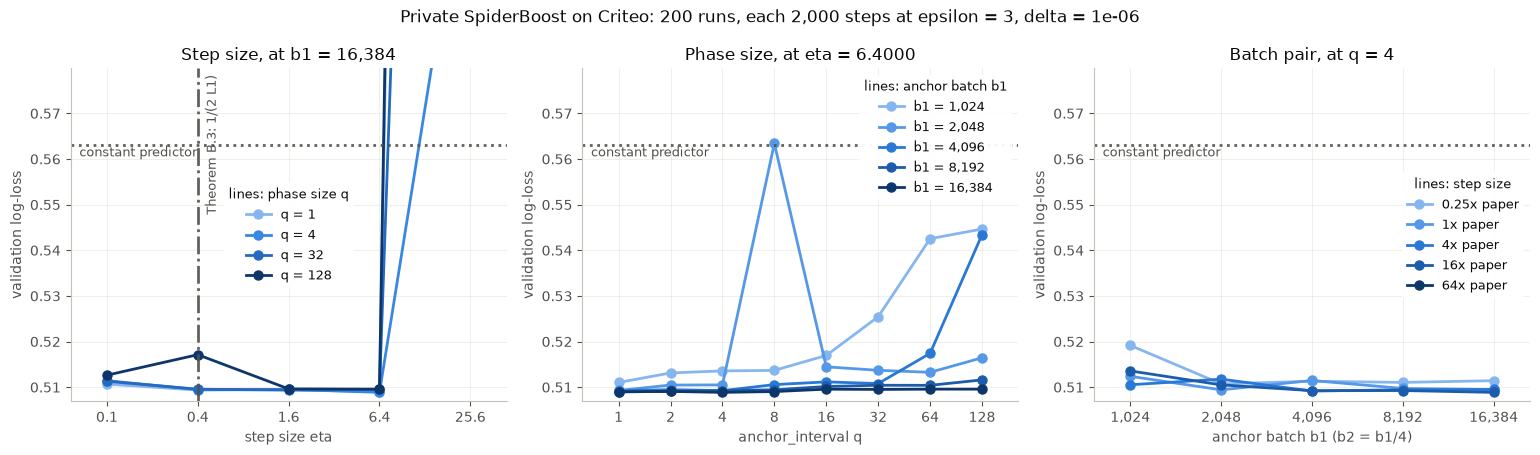

In [11]:
CONST_VAL_LOSS = log_loss(np.full_like(Y_VAL_NP, VAL_BASE_RATE), Y_VAL_NP)
BEST_LOSS = BEST_SCORES.loss

# Panel 1 groups by phase size, which carries more values than an
# ordinal ramp can separate by lightness. Four are drawn, spanning the
# axis end to end; the full axis is in the table above.
LINES_PER_PANEL = 4
last_index = len(ANCHOR_INTERVAL_GRID) - 1
spaced = [round(i * last_index / (LINES_PER_PANEL - 1))
          for i in range(LINES_PER_PANEL)]
PANEL_INTERVALS = tuple(dict.fromkeys(ANCHOR_INTERVAL_GRID[i] for i in spaced))

fig, (left, middle, right) = plt.subplots(1, 3, figsize=(15.5, 4.6))

for colour, interval in zip(RAMP_4, PANEL_INTERVALS):
    rows = [row for row in SWEEP
            if row.config.anchor_interval == interval
            and row.config.b1 == BEST_CONFIG.b1]
    rows.sort(key=lambda row: row.config.step_scale)
    left.plot([row.config.step_size for row in rows],
              [row.scores.loss for row in rows],
              marker="o", color=colour, label=f"q = {interval}")

for colour, (b1, b2) in zip(RAMP_5, BATCH_GRID):
    rows = [row for row in SWEEP if row.config.b1 == b1
            and row.config.step_scale == BEST_CONFIG.step_scale]
    rows.sort(key=lambda row: row.config.anchor_interval)
    middle.plot([row.config.anchor_interval for row in rows],
                [row.scores.loss for row in rows],
                marker="o", color=colour, label=f"b1 = {b1:,}")

for colour, scale in zip(RAMP_5, STEP_SCALE_GRID):
    rows = [row for row in SWEEP if row.config.step_scale == scale
            and row.config.anchor_interval == BEST_CONFIG.anchor_interval]
    rows.sort(key=lambda row: row.config.b1)
    right.plot([row.config.b1 for row in rows],
               [row.scores.loss for row in rows],
               marker="o", color=colour, label=f"{scale:g}x paper")

left.axvline(PAPER_STEP_SIZE, color=MUTED, linestyle="-.", alpha=0.9)
left.annotate("Theorem B.3: 1/(2 L1)", xy=(PAPER_STEP_SIZE, 0.98),
              xycoords=left.get_xaxis_transform(), xytext=(5, 0),
              textcoords="offset points", color=MUTED, fontsize=9,
              rotation=90, va="top")


class Panel(NamedTuple):
    """One panel of the sweep figure, and how its axis is labelled."""

    axis: object
    title: str
    xlabel: str
    legend_title: str
    ticks: list
    tick_label: object


def as_plain(value):
    return f"{value:g}"


def as_count(value):
    return f"{value:,}"


# A log axis left to itself labels its decades and crowds the minor ticks
# between them; these axes have five or eight points and those are what
# the reader wants a label on.
step_ticks = [scale * PAPER_STEP_SIZE for scale in STEP_SCALE_GRID]
interval_ticks = list(ANCHOR_INTERVAL_GRID)
batch_ticks = [b1 for b1, _ in BATCH_GRID]

PANELS = (
    Panel(left, f"Step size, at b1 = {BEST_CONFIG.b1:,}", "step size eta",
          "lines: phase size q", step_ticks, as_plain),
    Panel(middle, f"Phase size, at eta = {BEST_CONFIG.step_size:.4f}",
          "anchor_interval q", "lines: anchor batch b1",
          interval_ticks, as_plain),
    Panel(right, f"Batch pair, at q = {BEST_CONFIG.anchor_interval}",
          "anchor batch b1 (b2 = b1/4)", "lines: step size",
          batch_ticks, as_count),
)
for panel in PANELS:
    axis = panel.axis
    axis.axhline(CONST_VAL_LOSS, color=MUTED, linestyle=":", alpha=0.9)
    axis.text(0.02, CONST_VAL_LOSS, "constant predictor", color=MUTED,
              fontsize=9, va="top", transform=axis.get_yaxis_transform())
    axis.set_xscale("log")
    axis.set_xticks(panel.ticks)
    axis.set_xticklabels([panel.tick_label(tick) for tick in panel.ticks])
    axis.minorticks_off()
    axis.margins(x=0.10)
    axis.set_ylim(BEST_LOSS - 0.002, CONST_VAL_LOSS * 1.03)
    axis.set_xlabel(panel.xlabel)
    axis.set_ylabel("validation log-loss")
    axis.set_title(panel.title)
    # A solid surface-coloured patch behind the legend: these panels
    # carry reference lines that would otherwise run through the
    # entries. No edge, so it adds no ink of its own.
    axis.legend(title=panel.legend_title, fontsize=9, title_fontsize=9,
                frameon=True, facecolor="white", edgecolor="none",
                framealpha=0.95)
    axis.grid(alpha=0.5)

fig.suptitle(f"Private SpiderBoost on Criteo: {len(SWEEP)} runs, each "
             f"{STEPS:,} steps at epsilon = {TARGET_EPSILON:g}, "
             f"delta = {TARGET_DELTA}", color=INK)
fig.tight_layout()
plt.show()

In [12]:
def loss_at(rows, coordinates):
    """The one grid row at these coordinates, or nan if there is none."""
    for row in rows:
        if all(getattr(row.config, field) == value
               for field, value in coordinates.items()):
            return row.scores.loss
    return float("nan")


def show_matrix(rows, row_axis, column_axis, held_axis, config):
    """The validation log-loss behind one panel of the figure.

    One row per line the panel draws, one column per point on its
    horizontal, with the third axis pinned where the panel pinned it.
    """
    held_value = getattr(config, held_axis.field)
    print(f"validation log-loss: {row_axis.short} down, "
          f"{column_axis.short} across, at {held_axis.short} = "
          f"{held_value:g}")
    header = "".join(f"{value:>9g}" for value in column_axis.values)
    print(f"  {row_axis.short:>8}{header}")
    for row_value in row_axis.values:
        cells = []
        for column_value in column_axis.values:
            coordinates = {row_axis.field: row_value,
                           column_axis.field: column_value,
                           held_axis.field: held_value}
            cells.append(f"{loss_at(rows, coordinates):>9.4f}")
        body = "".join(cells)
        print(f"  {row_value:>8g}{body}")
    print()


show_matrix(SWEEP, PHASE_AXIS, STEP_AXIS, BATCH_AXIS, BEST_CONFIG)
show_matrix(SWEEP, BATCH_AXIS, PHASE_AXIS, STEP_AXIS, BEST_CONFIG)
show_matrix(SWEEP, STEP_AXIS, BATCH_AXIS, PHASE_AXIS, BEST_CONFIG)
print(f"the selected configuration is q = {BEST_CONFIG.anchor_interval}, "
      f"b1 = {BEST_CONFIG.b1}, {BEST_CONFIG.step_scale:g}x the paper's step "
      f"size, at validation log-loss {BEST_SCORES.loss:.4f}.")

validation log-loss: q down, x paper across, at b1 = 16384
         q     0.25        1        4       16       64
         1   0.5107   0.5094   0.5095   0.5090   1.5839
         2   0.5116   0.5117   0.5089   0.5091   0.8309
         4   0.5114   0.5095   0.5095   0.5089   0.6331
         8   0.5148   0.5094   0.5092   0.5090   0.9798
        16   0.5113   0.5197   0.5090   0.5096   0.8667
        32   0.5113   0.5096   0.5094   0.5095   1.0737
        64   0.5106   0.5105   0.5096   0.5096   1.1214
       128   0.5126   0.5171   0.5096   0.5096   1.7074

validation log-loss: b1 down, q across, at x paper = 16
        b1        1        2        4        8       16       32       64      128
      1024   0.5110   0.5131   0.5136   0.5137   0.5170   0.5254   0.5425   0.5447
      2048   0.5093   0.5105   0.5105   0.5634   0.5145   0.5137   0.5133   0.5164
      4096   0.5092   0.5095   0.5092   0.5106   0.5112   0.5108   0.5174   0.5434
      8192   0.5090   0.5091   0.5093   0.5094  

### Reading the three axes

**The yardstick first, and it is not one number.** Section 5 re-runs two
configurations at five seeds each and gets validation log-loss spreads of
**0.0007** at the selected configuration (`q = 4`, `b1 = 16,384`, 16x) and
**0.0074** at the lowest-loss row using Theorem B.3's step size (`q = 1`,
`b1 = 4,096`, 1x). Those differ by an order of magnitude, so this grid has no
single noise floor: run-to-run variance is small at the large-batch corner the
selection landed in and ten times larger at the degenerate small-`q` corner.
The grid runs each point once, at a seed folded off its position, so **the seed
varies with the configuration** as well.

Applied conservatively — against the **wider** `0.0074` — **only two things in
this grid are resolved**: the phase-size cost at a small anchor batch, and the
step-size blow-up. Everything else below is a suggestive monotone trend with a
mechanism behind it, and is written as one.

**The batch pair: a monotone trend that does not clear the conservative bound.**
At the selected phase size and step size, validation log-loss runs
`0.5136 → 0.5105 → 0.5092 → 0.5093 → 0.5089` and PR-AUC
`0.4377 → 0.4466 → 0.4483 → 0.4486 → 0.4507` as `b1` goes 1,024 → 16,384. The
whole axis spans `0.0047` and its first two steps `0.0044` — six times the
`0.0007` spread measured at the top of the axis, but **below the `0.0074`
measured at the small-batch end, which is precisely the end those two steps run
through**. So the reading is: monotone in the direction the mechanism predicts,
worth reporting, and not established by this file. What it is not is bracketed:
`b1 = 16,384` wins at the end of the axis, the last three points span `0.0004`,
and extending the axis another octave would find the same edge an octave out.

**The step size: an interior selection, and a collapse that is unambiguous.**
`0.5114` at a quarter of Theorem B.3's value, `0.5095` at the paper's, `0.5095`
at 4x, `0.5089` at the selected 16x, and `0.6331` at 64x. The first four span
`0.0025` — inside `0.0074`, so the shape of the interior is suggestive only, and
"the selected value is interior to this axis" is a statement about where the
minimum of five one-seed runs fell rather than about where the optimum is. The
64x point is different in kind: `+0.124` on the winner and well past the
constant predictor, and across the whole batch axis at 64x the row reads
`1.0430, 1.2519, 1.9256, 1.5845, 0.6331`. That is the algorithm giving up: it
clears the conservative spread by between seventeen and two hundred times
depending on the cell, and it is what makes the top of this axis a real edge
rather than an unexplored one.

**The phase size does not separate at all at the selected batch pair.** Its
eight values span `0.5089` to `0.5096` — `0.0007`, which is the narrow spread
exactly and a tenth of the wide one. The selected `q = 4` is interior and that
interiority is worth nothing: `q = 1`, which is not Algorithm 2 but unclipped
noisy SGD, scores `0.5090`.

**But that is a fact about one batch pair, and it is the one resolved finding
here that runs the other way.** The middle matrix above, at sixteen times the
paper's step size:

| `b1` | q = 1 | q = 8 | q = 32 | q = 128 |
|---|---|---|---|---|
| 1,024 | 0.5110 | 0.5137 | 0.5254 | 0.5447 |
| 4,096 | 0.5092 | 0.5106 | 0.5108 | 0.5434 |
| 16,384 | 0.5090 | 0.5090 | 0.5095 | 0.5096 |

A long phase costs `+0.0337` at `b1 = 1,024` — four and a half times the
conservative `0.0074`, and monotone across all eight columns — against `+0.0006`
at `b1 = 16,384`. The same climb appears at `b1 = 4,096`, `+0.0342` end to end,
so it is not one row's accident. That is the mechanism
doing what it should: a phase is one anchor estimate reused for `q - 1`
variation steps, and that anchor's noise is `sigma_1 = mu·L0/b1`, so how long a
phase a run can afford is set by how good its anchor is. **The phase size and
the anchor batch are one axis, not two**, and the only reason this sweep sees a
flat `q` is that it selected the largest anchor batch on the grid.

One cell of that matrix is worth flagging rather than smoothing over:
`b1 = 2,048, q = 8` scores `0.5634`, level with the constant predictor and
`0.05` off both its neighbours on that row. It clears the conservative spread
several times over but it is a single run at a single seed with no neighbour
supporting it, so it is an outlier rather than a finding. It stays in the table,
because a grid that quietly drops its outliers is a grid whose flat regions
cannot be trusted either.

### The step size, and what Theorem B.3's value costs

Theorem B.3 fixes the step size at `1/(2·L1)`. Departing from it leaves the
privacy untouched — the accountant never sees a step size — but drops the
convergence guarantee *and* changes how far the parameters move per step, which
is exactly what the variation branch's noise scales against. So a different
step size is a different mechanism, not the same one run faster. The decision
here is to sweep it like any other axis and report both.

**The contrast below is the matched one**: the selected phase size and batch
pair, moved one point along the step-size axis and nothing else. A gap read off
two configurations that differ on more than the axis under test is not a
reading of that axis, which is why the lowest-loss `1x` row *anywhere* in the
grid is printed separately and labelled as the different shape it is.

In [13]:
# The matched contrast, and the one this notebook headlines: the same
# phase size and the same batch pair as the winner, moved one point along
# the step-size axis and nothing else. A gap read off two configurations
# that differ on more than the axis under test is not a reading of that
# axis.
step_rows = profile(SWEEP, STEP_AXIS, BEST_CONFIG)
matched_paper = next(row for row in step_rows
                     if row.config.step_scale == 1.0)

# And, separately, the lowest-loss 1x row anywhere in the grid, which is a
# different shape and is reported as one.
paper_rows = [row for row in finite(SWEEP) if row.config.step_scale == 1.0]
BEST_PAPER = min(paper_rows, key=lambda row: row.scores.loss)

print(f"Theorem B.3's step size at R = {FEATURE_NORM_BOUND} with a bias: "
      f"eta = {PAPER_STEP_SIZE:.6f}")
print()
if BEST_CONFIG.step_scale == 1.0:
    print("The selection landed on it. The reported model therefore keeps "
          "the convergence guarantee as well as the privacy, and there is "
          "nothing to trade off.")
else:
    matched_scores = matched_paper.scores
    loss_gap = matched_scores.loss - BEST_SCORES.loss
    pr_gap = matched_scores.pr_auc - BEST_SCORES.pr_auc
    print("The selection did NOT land on it. The matched contrast, at the "
          "selected phase size and batch pair:")
    print(f"  q = {BEST_CONFIG.anchor_interval}, b1 = {BEST_CONFIG.b1}, "
          f"b2 = {BEST_CONFIG.b2}")
    print(f"    selected  {BEST_CONFIG.step_scale:>4g}x  "
          f"eta = {BEST_CONFIG.step_size:>8.4f}   val log-loss "
          f"{BEST_SCORES.loss:.4f}   PR-AUC {BEST_SCORES.pr_auc:.4f}")
    print(f"    paper's   {matched_paper.config.step_scale:>4g}x  "
          f"eta = {matched_paper.config.step_size:>8.4f}   val log-loss "
          f"{matched_scores.loss:.4f}   PR-AUC {matched_scores.pr_auc:.4f}")
    print(f"    the paper's value costs {loss_gap:+.4f} validation log-loss "
          f"and {pr_gap:+.4f} PR-AUC, at the same epsilon, on the "
          f"output-rule iterate.")
    print()
    print("Separately, the lowest-loss 1x row anywhere in the grid — a "
          "different shape, so not a reading of the step-size axis:")
    print(f"    q = {BEST_PAPER.config.anchor_interval}, "
          f"b1 = {BEST_PAPER.config.b1}, b2 = {BEST_PAPER.config.b2}, "
          f"val log-loss {BEST_PAPER.scores.loss:.4f}, "
          f"PR-AUC {BEST_PAPER.scores.pr_auc:.4f}")
    if BEST_PAPER.config.anchor_interval == 1:
        print("    that row sits at q = 1, which is the degenerate end of "
              "the phase-size axis: unclipped noisy SGD, not Algorithm 2.")

print()
print("the step-size axis at the selected q and batch pair, in full:")
for row in step_rows:
    tags = []
    if row.config.step_scale == 1.0:
        tags.append("Theorem B.3")
    if row.config == BEST_CONFIG:
        tags.append("selected")
    tag = ("   <- " + ", ".join(tags)) if tags else ""
    print(f"  {row.config.step_scale:>6g}x  eta = {row.config.step_size:>9.4f}"
          f"   val log-loss {row.scores.loss:>9.4f}   "
          f"PR-AUC {row.scores.pr_auc:.4f}{tag}")

Theorem B.3's step size at R = 2.0 with a bias: eta = 0.400000

The selection did NOT land on it. The matched contrast, at the selected phase size and batch pair:
  q = 4, b1 = 16384, b2 = 4096
    selected    16x  eta =   6.4000   val log-loss 0.5089   PR-AUC 0.4507
    paper's      1x  eta =   0.4000   val log-loss 0.5095   PR-AUC 0.4462
    the paper's value costs +0.0006 validation log-loss and -0.0045 PR-AUC, at the same epsilon, on the output-rule iterate.

Separately, the lowest-loss 1x row anywhere in the grid — a different shape, so not a reading of the step-size axis:
    q = 1, b1 = 4096, b2 = 1024, val log-loss 0.5094, PR-AUC 0.4470
    that row sits at q = 1, which is the degenerate end of the phase-size axis: unclipped noisy SGD, not Algorithm 2.

the step-size axis at the selected q and batch pair, in full:
    0.25x  eta =    0.1000   val log-loss    0.5114   PR-AUC 0.4384
       1x  eta =    0.4000   val log-loss    0.5095   PR-AUC 0.4462   <- Theorem B.3
       4x  et

## 5. How much of that is the seed?

The grid runs each configuration once, at a seed folded off its position, so
every gap in section 4 carries one draw of the sampling stream, one draw of the
noise stream **and one draw of the output rule** — Algorithm 2 returns a
uniformly chosen iterate, which is run-to-run variance a last-iterate method
does not have. A gap smaller than that variance is not a finding.

So two configurations are re-run at five seeds each: the selected one, and the
lowest-loss row in the grid at Theorem B.3's step size — which, in the run this
file carries, is at `q = 1`, the degenerate end where the algorithm is unclipped
noisy SGD rather than Algorithm 2. The pair is deliberate: **the point is not a
single noise floor but how much the noise floor moves across the grid.** The
initialization does not move; the sampling stream, the noise stream and the
output-rule draw do. Five seeds is a spread, not a confidence interval, and it
is reported as min/max.

The same cell shows the selected configuration's **last iterate** beside its
output-rule iterate, once. No bound covers the last iterate — no gradient
estimate was ever taken at it — and nothing in this notebook reports it.

In [14]:
def repeats_of(config, label):
    """Five re-runs of one configuration, differing only in their streams."""
    # The same seed list for both configurations, so the two spreads are
    # paired rather than two independent draws.
    jobs = [config._replace(seed_index=REPEAT_SEED_BASE + seed)
            for seed in SEEDS]
    with ThreadPoolExecutor(max_workers=WORKERS) as pool:
        rows = list(pool.map(run_and_score, jobs))
    losses = [row.scores.loss for row in rows]
    pr_aucs = [row.scores.pr_auc for row in rows]
    print(f"{label}")
    print(f"  val log-loss  mean {np.mean(losses):.4f}  "
          f"[{min(losses):.4f}, {max(losses):.4f}]  "
          f"spread {max(losses) - min(losses):.4f}")
    print(f"  val PR-AUC    mean {np.mean(pr_aucs):.4f}  "
          f"[{min(pr_aucs):.4f}, {max(pr_aucs):.4f}]  "
          f"spread {max(pr_aucs) - min(pr_aucs):.4f}")
    return rows


selected_label = (
    f"the selected configuration: q = {BEST_CONFIG.anchor_interval}, "
    f"b1 = {BEST_CONFIG.b1}, b2 = {BEST_CONFIG.b2}, "
    f"eta = {BEST_CONFIG.step_size:.4f} ({BEST_CONFIG.step_scale:g}x paper)")
paper_config = BEST_PAPER.config
degenerate = " -- the degenerate q = 1 end" if paper_config.anchor_interval == 1 else ""
paper_label = (
    f"the best 1x row in the grid{degenerate}: "
    f"q = {paper_config.anchor_interval}, b1 = {paper_config.b1}, "
    f"b2 = {paper_config.b2}, eta = {paper_config.step_size:.4f}")

t0 = time.time()
SELECTED_REPEATS = repeats_of(BEST_CONFIG, selected_label)
print()
PAPER_REPEATS = repeats_of(paper_config, paper_label)

def spread_of(rows):
    losses = [row.scores.loss for row in rows]
    return max(losses) - min(losses)


SELECTED_SPREAD = spread_of(SELECTED_REPEATS)
PAPER_SPREAD = spread_of(PAPER_REPEATS)
print()
print(f"the two log-loss spreads over {len(SEEDS)} seeds: "
      f"{SELECTED_SPREAD:.4f} at the selected configuration, "
      f"{PAPER_SPREAD:.4f} at the other one.")
print("They differ by an order of magnitude, so there is no single noise "
      "floor for this grid. A difference in section 4 is read against the "
      "spread measured nearest to it, and where that is, is stated with "
      "the difference; a difference under the WIDER of the two is not "
      "resolved anywhere in this file.")
print(f"\n({time.time() - t0:.0f}s)")

the selected configuration: q = 4, b1 = 16384, b2 = 4096, eta = 6.4000 (16x paper)
  val log-loss  mean 0.5092  [0.5090, 0.5097]  spread 0.0007
  val PR-AUC    mean 0.4482  [0.4457, 0.4495]  spread 0.0038



the best 1x row in the grid -- the degenerate q = 1 end: q = 1, b1 = 4096, b2 = 1024, eta = 0.4000
  val log-loss  mean 0.5123  [0.5093, 0.5167]  spread 0.0074
  val PR-AUC    mean 0.4392  [0.4321, 0.4472]  spread 0.0151

the two log-loss spreads over 5 seeds: 0.0007 at the selected configuration, 0.0074 at the other one.
They differ by an order of magnitude, so there is no single noise floor for this grid. A difference in section 4 is read against the spread measured nearest to it, and where that is, is stated with the difference; a difference under the WIDER of the two is not resolved anywhere in this file.

(41s)


In [15]:
output_params, last_params = fit(BEST_CONFIG)
OUTPUT_RULE_SCORES = evaluate_at(output_params, X_VAL, Y_VAL_NP)
LAST_ITERATE_SCORES = evaluate_at(last_params, X_VAL, Y_VAL_NP)
REPORTED_PARAMS = output_params

print("the selected configuration's two iterates, on validation:")
print(f"  {'':<36}{'log-loss':>10}{'PR-AUC':>9}{'ECE':>9}")
print(f"  {'output rule (w-bar, reported)':<36}"
      f"{OUTPUT_RULE_SCORES.loss:10.4f}{OUTPUT_RULE_SCORES.pr_auc:9.4f}"
      f"{OUTPUT_RULE_SCORES.ece:9.4f}")
print(f"  {'last iterate (no bound covers it)':<36}"
      f"{LAST_ITERATE_SCORES.loss:10.4f}{LAST_ITERATE_SCORES.pr_auc:9.4f}"
      f"{LAST_ITERATE_SCORES.ece:9.4f}")
print(f"\n  gap (last - output rule): log-loss "
      f"{LAST_ITERATE_SCORES.loss - OUTPUT_RULE_SCORES.loss:+.4f}, PR-AUC "
      f"{LAST_ITERATE_SCORES.pr_auc - OUTPUT_RULE_SCORES.pr_auc:+.4f}")
print("\nEverything below reports the output-rule iterate.")

the selected configuration's two iterates, on validation:
                                        log-loss   PR-AUC      ECE
  output rule (w-bar, reported)           0.5089   0.4507   0.0059
  last iterate (no bound covers it)       0.5093   0.4492   0.0072

  gap (last - output rule): log-loss +0.0004, PR-AUC -0.0015

Everything below reports the output-rule iterate.


## 6. The selected configuration over training steps

Hold the phase size, the batch pair and the step size at the values section 4
picked, and vary only how long the run trains. **Each point is an independent
run** at its own recalibrated noise scales — the private loop returns no
optimizer state, no estimator state and no phase position, precisely so that a
run cannot be resumed and replay its noise stream, so a chunked curve would be
a different mechanism rather than the same run observed more often.

Because each point is recalibrated over exactly the steps it runs, **every
point on this curve spends the same ε = 3**: a longer run here is not a more
expensive run, it is the same budget spread over more, noisier releases. That is
the question this section exists to answer, and the reason the trajectory runs
past the sweep's 2,000 steps all the way to notebook 05's 10,000: it measures
what the wall-clock cap cost.

In [16]:
for steps in TRAJECTORY_STEPS:
    calibrate(steps, BEST_CONFIG.anchor_interval, BEST_CONFIG.b1,
              BEST_CONFIG.b2)

def trajectory_job(index, steps):
    config = BEST_CONFIG._replace(seed_index=TRAJECTORY_SEED_BASE + index)
    return TrajectoryJob(steps=steps, config=config)


def run_trajectory_point(job):
    return run_and_score(job.config, steps=job.steps)


trajectory_jobs = [trajectory_job(index, steps)
                   for index, steps in enumerate(TRAJECTORY_STEPS)]

t0 = time.time()
with ThreadPoolExecutor(max_workers=WORKERS) as pool:
    TRAJECTORY = list(pool.map(run_trajectory_point, trajectory_jobs))
TRAJECTORY_SECONDS = time.time() - t0

print(f"q = {BEST_CONFIG.anchor_interval}, b1 = {BEST_CONFIG.b1}, "
      f"b2 = {BEST_CONFIG.b2}, eta = {BEST_CONFIG.step_size:.4f}, "
      f"one independent run per row, each at epsilon = {TARGET_EPSILON:g}")
print(f"  {'steps':>7} {'sigma_1':>12} {'sigma_2':>12} {'epsilon':>9} "
      f"{'val log-loss':>13} {'val PR-AUC':>11} {'val ECE':>9}")
for steps, row in zip(TRAJECTORY_STEPS, TRAJECTORY):
    shape = (steps, BEST_CONFIG.anchor_interval, BEST_CONFIG.b1,
             BEST_CONFIG.b2)
    scales, spent = SCALES[shape], EPSILON_BACK[shape]
    mark = "  <- the sweep's step count" if steps == STEPS else ""
    print(f"  {steps:>7,} {scales.anchor_noise_scale:>12.4e} "
          f"{scales.variation_noise_rate:>12.4e} {spent:>9.6f} "
          f"{row.scores.loss:>13.4f} {row.scores.pr_auc:>11.4f} "
          f"{row.scores.ece:>9.4f}{mark}")
print(f"\n{len(TRAJECTORY)} independent runs in {TRAJECTORY_SECONDS:.0f}s "
      f"across {WORKERS} threads; every row is the output-rule iterate.")

q = 4, b1 = 16384, b2 = 4096, eta = 6.4000, one independent run per row, each at epsilon = 3
    steps      sigma_1      sigma_2   epsilon  val log-loss  val PR-AUC   val ECE
      125   1.1656e-04   2.6064e-04  2.999992        0.5116      0.4372    0.0089
      250   1.2231e-04   2.7349e-04  3.000000        0.5111      0.4384    0.0058
      500   1.3059e-04   2.9202e-04  2.999992        0.5092      0.4501    0.0082
    1,000   1.4393e-04   3.2184e-04  2.999999        0.5091      0.4491    0.0066
    2,000   1.6813e-04   3.7595e-04  2.999997        0.5095      0.4471    0.0069  <- the sweep's step count
    4,000   2.1090e-04   4.7158e-04  3.000000        0.5091      0.4492    0.0068
   10,000   3.0600e-04   6.8424e-04  3.000000        0.5089      0.4502    0.0061

7 independent runs in 53s across 8 threads; every row is the output-rule iterate.


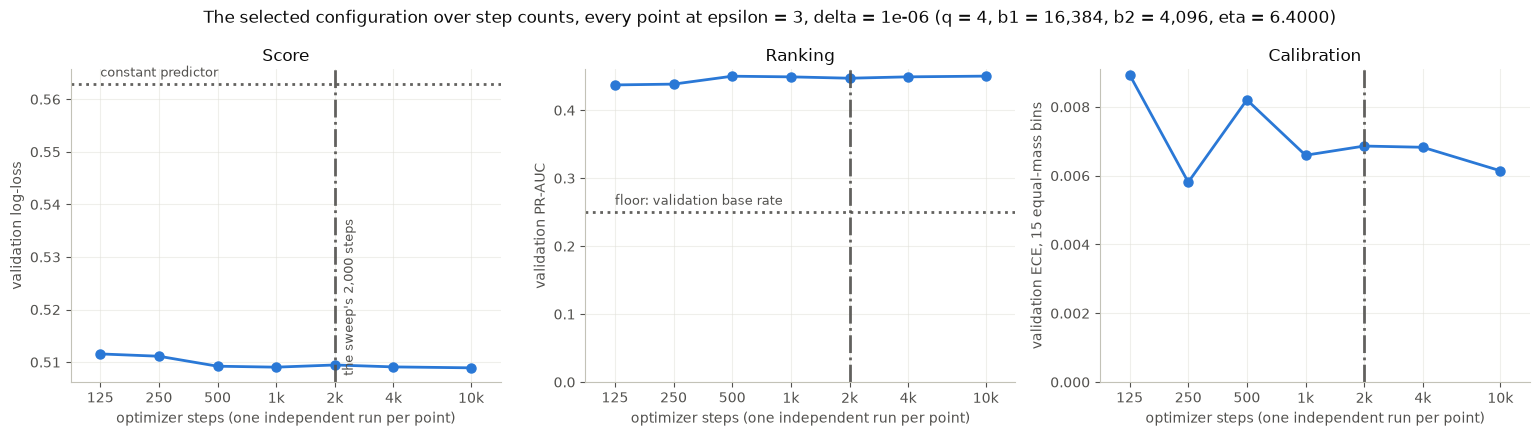

In [17]:
steps_axis = list(TRAJECTORY_STEPS)
loss_axis = [row.scores.loss for row in TRAJECTORY]
pr_axis = [row.scores.pr_auc for row in TRAJECTORY]
ece_axis = [row.scores.ece for row in TRAJECTORY]

fig, (left, middle, right) = plt.subplots(1, 3, figsize=(15.5, 4.4))

left.plot(steps_axis, loss_axis, marker="o", color=ACCENT)
left.axhline(CONST_VAL_LOSS, color=MUTED, linestyle=":", alpha=0.9)
left.annotate("constant predictor", xy=(steps_axis[0], CONST_VAL_LOSS),
              xytext=(0, 5), textcoords="offset points", color=MUTED,
              fontsize=9)
left.set_ylabel("validation log-loss")
left.set_title("Score")

middle.plot(steps_axis, pr_axis, marker="o", color=ACCENT)
middle.axhline(VAL_BASE_RATE, color=MUTED, linestyle=":", alpha=0.9)
middle.annotate("floor: validation base rate",
                xy=(steps_axis[0], VAL_BASE_RATE), xytext=(0, 5),
                textcoords="offset points", color=MUTED, fontsize=9)
middle.set_ylabel("validation PR-AUC")
middle.set_ylim(bottom=0.0)
middle.set_title("Ranking")

# ECE is an upward-biased estimate, so the distance from zero is not a
# calibration error; only the movement across this panel is readable, and
# every point is the same bin count on the same evaluation set.
right.plot(steps_axis, ece_axis, marker="o", color=ACCENT)
right.set_ylabel(f"validation ECE, {N_BINS} equal-mass bins")
right.set_ylim(bottom=0.0)
right.set_title("Calibration")

def as_steps(value):
    return f"{value // 1000:g}k" if value >= 1000 else f"{value:g}"


for axis in (left, middle, right):
    axis.axvline(STEPS, color=MUTED, linestyle="-.", alpha=0.9)
    axis.set_xlabel("optimizer steps (one independent run per point)")
    axis.set_xscale("log")
    axis.set_xticks(steps_axis)
    axis.set_xticklabels([as_steps(steps) for steps in steps_axis])
    axis.minorticks_off()
    axis.margins(x=0.08)
    axis.grid(alpha=0.5)
left.annotate(f"the sweep's {STEPS:,} steps", xy=(STEPS, 0.02),
              xycoords=left.get_xaxis_transform(), xytext=(5, 0),
              textcoords="offset points", color=MUTED, fontsize=9,
              rotation=90, va="bottom")

fig.suptitle(f"The selected configuration over step counts, every point at "
             f"epsilon = {TARGET_EPSILON:g}, delta = {TARGET_DELTA} "
             f"(q = {BEST_CONFIG.anchor_interval}, b1 = {BEST_CONFIG.b1:,}, "
             f"b2 = {BEST_CONFIG.b2:,}, eta = "
             f"{BEST_CONFIG.step_size:.4f})", color=INK)
fig.tight_layout()
plt.show()

### What the 2,000-step cap cost

**Nothing this file can measure, and the trajectory is how that is known rather
than hoped.** Validation log-loss at the selected configuration reads `0.5116`
at 125 steps and `0.5111` at 250, then `0.5092`, `0.5091`, `0.5095`, `0.5091`
and `0.5089` at 500, 1,000, 2,000, 4,000 and 10,000. The descent is over inside
the first 500 steps; from there to 10,000 — a twentyfold increase in wall-clock
— the score falls `0.0003` and never moves more than `0.0006`.

The specific comparison the cap needs: **at this configuration the sweep's 2,000
steps score `0.5095` and 10,000 steps — notebook 05's count, run here — score
`0.5089`** — `0.0006` — and the same
`0.0006` separates this row from the sweep's own 2,000-step run of the identical
configuration, which scored `0.5089` and differs from this one only in its seed.
Both sit under the `0.0007` spread measured at this very configuration, and far
under the `0.0074` measured elsewhere. **The cap is inside the noise at the
configuration where it was measured**, so the sweep's rankings are the rankings
a 10,000-step sweep would have produced — at this configuration. Whether it
reorders the rest of the grid is not measured here, and the axes whose trends
already fail to clear the conservative spread are the ones a reordering would
show up in first.

**Note also what does not happen: more steps do not cost more privacy here.**
Each point recalibrates over exactly its own step count, so the 10,000-step run
spends the same ε = 3 as the 125-step run and pays for the extra 9,875 releases
in noise instead — `sigma_1` rises `1.1656e-04 → 3.0600e-04` down the table, a
factor of 2.6. At this budget and this anchor batch that trade is almost free:
the extra noise per release is bought back by the extra averaging. It would not
be at a tighter ε, and nothing here speaks to that.

## 7. The operating point, then the test split

A confusion matrix is a quantity at a threshold, and a threshold is a choice.
It is made here by one rule, on validation, and frozen before the test split is
read: **the threshold that maximises F1 on the validation split**
(`best_f1_threshold`, which takes every observed score as a candidate and so
finds the exact maximiser rather than approximating it). Choosing it on test
would make every number after it a fitted quantity. Which split a threshold was
chosen on is the caller's to state, and this paragraph is that statement
(ADR-0016).

The model reported below is the **output-rule iterate of a single run** of the
selected configuration at 2,000 steps — the run in section 5, on the sweep's own
stream for that configuration. Its ε is the one section 2 calibrated and section
2 reported back.

In [18]:
val_probs = probabilities(REPORTED_PARAMS, X_VAL)
val_point = best_f1_threshold(val_probs, Y_VAL_NP)
THRESHOLD = val_point.threshold

print(f"validation-optimal threshold p >= {THRESHOLD:.4f}   "
      f"val F1 = {val_point.f1:.4f}")
print("chosen on validation, frozen here, before the test split is read.")

validation-optimal threshold p >= 0.2534   val F1 = 0.4915
chosen on validation, frozen here, before the test split is read.


In [19]:
# The first read of the test split in this notebook.
Y_TEST_NP = np.asarray(Y_TEST, dtype=np.float64)
TEST_BASE_RATE = float(Y_TEST_NP.mean())
test_probs = probabilities(REPORTED_PARAMS, X_TEST)
TEST_CURVE = pr_curve(test_probs, Y_TEST_NP)
TEST_CONFUSION = confusion_at(test_probs, Y_TEST_NP, THRESHOLD)

test_loss = log_loss(test_probs, Y_TEST_NP)
test_ece = expected_calibration_error(test_probs, Y_TEST_NP, n_bins=N_BINS)
TEST_SCORES = Eval(loss=test_loss, pr_auc=TEST_CURVE.average_precision,
                   ece=test_ece)
TEST_NE = normalized_entropy(test_probs, Y_TEST_NP)
TEST_CAL_RATIO = calibration_ratio(test_probs, Y_TEST_NP)

const_probs = np.full_like(Y_TEST_NP, TEST_BASE_RATE)
const_loss = log_loss(const_probs, Y_TEST_NP)
const_ne = normalized_entropy(const_probs, Y_TEST_NP)
const_ece = expected_calibration_error(const_probs, Y_TEST_NP, n_bins=N_BINS)
const_cal_ratio = calibration_ratio(const_probs, Y_TEST_NP)
print(f"test split: {len(Y_TEST_NP):,} rows, base rate "
      f"{TEST_BASE_RATE:.4f} (the PR-AUC floor)\n")
print(f"{'':<34}{'log-loss':>10}{'NE':>8}{'ECE':>8}{'cal-ratio':>11}"
      f"{'PR-AUC':>9}")
print(f"{'constant predictor':<34}{const_loss:10.4f}{const_ne:8.4f}"
      f"{const_ece:8.4f}{const_cal_ratio:11.4f}{TEST_BASE_RATE:9.4f}")
print(f"{'Private SpiderBoost (w-bar)':<34}{TEST_SCORES.loss:10.4f}"
      f"{TEST_NE:8.4f}{TEST_SCORES.ece:8.4f}{TEST_CAL_RATIO:11.4f}"
      f"{TEST_SCORES.pr_auc:9.4f}")
print()
print(f"one run, {STEPS:,} steps, output-rule iterate, at "
      f"q = {BEST_CONFIG.anchor_interval}, b1 = {BEST_CONFIG.b1}, "
      f"b2 = {BEST_CONFIG.b2}, eta = {BEST_CONFIG.step_size:.4f}, "
      f"epsilon = {TARGET_EPSILON:g}, delta = {TARGET_DELTA}, "
      f"{ACCOUNTANT.upper()} accounting.")

test split: 200,000 rows, base rate 0.2520 (the PR-AUC floor)

                                    log-loss      NE     ECE  cal-ratio   PR-AUC
constant predictor                    0.5645  1.0000  0.0000     1.0000   0.2520
Private SpiderBoost (w-bar)           0.5123  0.9075  0.0043     0.9951   0.4472

one run, 2,000 steps, output-rule iterate, at q = 4, b1 = 16384, b2 = 4096, eta = 6.4000, epsilon = 3, delta = 1e-06, RDP accounting.


In [20]:
def show_confusion(confusion, title, threshold):
    """The 2x2 as a table — four numbers do not need a chart.

    Every count is read by name: the four are transposed by accident when
    they are unpacked in a row.
    """
    caught = confusion.true_positives
    missed = confusion.false_negatives
    flagged_wrongly = confusion.false_positives
    left_alone = confusion.true_negatives
    predicted_positive = caught + flagged_wrongly
    actual_positive = caught + missed
    precision = caught / predicted_positive if predicted_positive else float("nan")
    recall = caught / actual_positive if actual_positive else float("nan")
    print(title)
    print(f"                 predicted no    predicted click")
    print(f"  actual no      {left_alone:>12,}    {flagged_wrongly:>15,}")
    print(f"  actual click   {missed:>12,}    {caught:>15,}")
    print(f"  precision {precision:.4f}   recall (TPR) {recall:.4f}   "
          f"F1 {2 * precision * recall / (precision + recall):.4f}   "
          f"(at threshold p >= {threshold:.4f})")
    return precision, recall


confusion_title = (
    f"Private SpiderBoost on the test split, output-rule iterate, "
    f"epsilon = {TARGET_EPSILON:g}")
TEST_PRECISION, TEST_RECALL = show_confusion(TEST_CONFUSION, confusion_title,
                                             THRESHOLD)

Private SpiderBoost on the test split, output-rule iterate, epsilon = 3
                 predicted no    predicted click
  actual no            98,862             50,738
  actual click         17,774             32,626
  precision 0.3914   recall (TPR) 0.6473   F1 0.4878   (at threshold p >= 0.2534)


The precision–recall curve, with PR-AUC in the title, the base rate as the floor
a random ranking reaches, and the chosen operating point marked. The curve is
the model's behaviour at every threshold; the marker is the one point the
confusion matrix above reports.

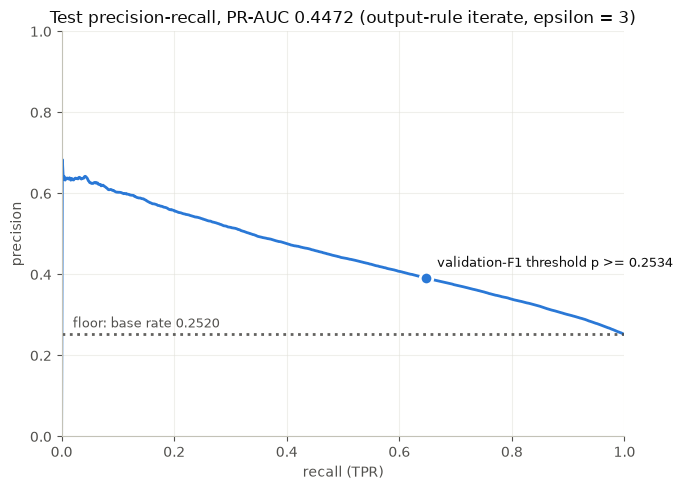

In [21]:
fig, axis = plt.subplots(figsize=(7, 5))

stride = max(1, len(TEST_CURVE.recall) // 2000)
axis.plot(TEST_CURVE.recall[::stride], TEST_CURVE.precision[::stride],
          color=ACCENT)
axis.plot([TEST_RECALL], [TEST_PRECISION], marker="o", markersize=9,
          color=ACCENT, linestyle="none", markeredgecolor="white",
          markeredgewidth=2)
axis.annotate(f"validation-F1 threshold p >= {THRESHOLD:.4f}",
              xy=(TEST_RECALL, TEST_PRECISION), xytext=(8, 8),
              textcoords="offset points", color=INK, fontsize=9)

axis.axhline(TEST_BASE_RATE, color=MUTED, linestyle=":", alpha=0.9)
axis.annotate(f"floor: base rate {TEST_BASE_RATE:.4f}",
              xy=(0.02, TEST_BASE_RATE), xytext=(0, 5),
              textcoords="offset points", color=MUTED, fontsize=9)
axis.set_xlabel("recall (TPR)")
axis.set_ylabel("precision")
axis.set_xlim(0, 1)
axis.set_ylim(0, 1)
axis.set_title(f"Test precision-recall, PR-AUC {TEST_SCORES.pr_auc:.4f} "
               f"(output-rule iterate, epsilon = {TARGET_EPSILON:g})")
axis.grid(alpha=0.5)
fig.tight_layout()
plt.show()

## What this shows, and what it does not

**At ε = 3, δ = 1e-6 by RDP, on 700,000 standardized full-file Criteo rows at
`R = 2.0`, the configuration this sweep selects is phase size `q = 4`, anchor
batch `b1 = 16,384`, variation batch `b2 = 4,096`, and a step size of `6.4` —
sixteen times Theorem B.3's `1/(2·L1) = 0.4`.** Calibrated by
`dimma.accounting.spiderboost` over exactly the 2,000 steps it runs, its three
noise scales are `sigma_1 = 1.6813e-04` on the anchor branch and
`sigma_2 = 3.7595e-04` with a cap of `1.3450e-03` on the variation branch, and
the accountant reads `2.999997` back from those three. Its **output-rule
iterate** — Algorithm 2's `w̄`, drawn uniformly from the iterates at which a
gradient estimate was released, and the iterate every number in this file is
read off — reaches test log-loss `0.5123` against the constant predictor's
`0.5645`, normalized entropy `0.9075`, PR-AUC `0.4472` against a base-rate floor
of `0.2520`, ECE `0.0043` at 15 equal-mass bins, and calibration ratio `0.9951`.
At the validation-F1 threshold `p >= 0.2534`, frozen before the test split was
read, it catches `32,626` of the `50,400` test clicks and raises `50,738` false
alarms: precision `0.3914`, recall `0.6473`, F1 `0.4878`.

**What the sweep resolves is less than what it ranks, and the difference is the
main thing to carry away.** The two five-seed spreads this file measures are
`0.0007` at the selected configuration and `0.0074` at the lowest-loss row
using the paper's step size, an order of magnitude apart, so there is no single
noise floor to quote. Read against the wider of them, **exactly two movements in
the 200-run grid are resolved**: the phase-size cost at a small anchor batch,
and the collapse at 64x the paper's step size. The batch-pair trend (`0.0047`
end to end) and the interior shape of the step-size axis (`0.0025`) clear the
narrow spread and not the wide one; they are reported as monotone trends with a
mechanism behind them, not as established differences. The phase size at the
selected batch pair spans `0.0007`, which resolves nothing under either bound —
and `q = 1`, the degenerate setting at which the algorithm is unclipped noisy
SGD rather than Algorithm 2, scores `0.5090` against the winner's `0.5089`.

**The one clear finding is that the phase size and the anchor batch are one
axis.** Going from `q = 1` to `q = 128` costs `+0.0337` in validation log-loss
at `b1 = 1,024` and `+0.0006` at `b1 = 16,384`. The first of those is four and a
half times the conservative spread and monotone across all eight columns, so it
is a difference this file can assert. A phase reuses a single anchor estimate
for `q - 1` variation steps and that estimate's noise is `mu·L0/b1`, so how long
a phase a run can afford is decided by how good its anchor is. A sweep that
fixes `b1` and reports the phase size as free has measured its own choice of
`b1` — which is, on the narrow reading, what this sweep did.

**Theorem B.3's step size costs nothing this file can measure.** The matched
contrast — same phase size, same batch pair, one point along the step-size axis
— is `0.5095` at the paper's `1x` against `0.5089` at the selected `16x`:
**`+0.0006`**, measured at `q = 4, b1 = 16,384`. That is under the `0.0007`
spread measured at that same configuration and far under the `0.0074` measured
at the other one, so the comparison and its yardstick sit at the same point of
the grid. (The lowest-loss `1x` row *anywhere* in the grid is a different shape
— `q = 1, b1 = 4,096`, at `0.5094`, and `q = 1` is the degenerate end — so it is
reported separately and is not a reading of the step-size axis.) The selection
rule chose `16x`; what the paper's value buys back is Theorem B.3's convergence
guarantee, for a difference the file cannot resolve. Privacy is not part of that
trade — the accountant never sees a step size — but the mechanism is: the
parameters move a different distance per step, and that distance is what the
variation branch's noise scales against, so `16x` is a different mechanism from
the one the theorem describes rather than the same one run faster.

**The result agrees with notebook 05 on the split the two files share.** That
notebook's Private SpiderBoost arm selected `b1 = 16,384, b2 = 4,096, q = 8`
at `4x` the paper's step size over 10,000 steps; this one selects the **same
batch pair**, the neighbouring phase size (`4` against `8`) and two rungs
further along the step-size axis (`16x` against `4x`). They are two nearby
points of the same grid, not the same configuration. On the test split — which
*is* identical across the two files, being the loader's own `seed=0` cut — 05
reports log-loss `0.5123`, PR-AUC `0.4466` and ECE `0.0038` against this file's
`0.5123`, `0.4472` and `0.0043`; each of those three gaps is inside the
three-seed spread notebook 05 itself measured for that arm. So a grid nearly
four times the size, at a fifth of the step count, arrived at a different point
of the same plateau and the same model out of it.

**The 2,000-step cap is a wall-clock compromise, and it is measured rather than
assumed.** Section 6 runs the selected configuration at seven step counts, each
recalibrated to the same ε over exactly the steps it takes: 2,000 steps score
`0.5095` and 10,000 score `0.5089`, and the same `0.0006` separates two runs of
the identical 2,000-step configuration at different seeds. The descent is over
by 500 steps. That is one configuration and not 200 — what is shown is that the
cap does not move *this* configuration; what is assumed is that it does not
reorder the grid.

**Not shown, and not claimed:**

- **One algorithm, and no baseline.** Notebook 05 is the comparison; this is the
  sweep.
- **The ε is assumed, not enforced** (ADR-0009). Algorithm 2 has no clipping line
  and dimma adds none, so every number above is a guarantee only if the shipped
  per-sample BCE really is `L0 = 2.236068`-Lipschitz and `L1 = 1.25`-smooth.
  Both constants come from `R = 2.0` and the bias flag alone (ADR-0012), `R` was
  written into the configuration block before the data was read, and nothing
  here or in the library checks the premise. A constant the data exceeds
  produces a false ε with no crash.
- **The validation rows are this file's own, not notebook 05's.** Same sizes and
  the same rule, a different stream root (`20260823` against `20260819`), so a
  different 100,000 rows — validation base rate `0.2506` here against 05's
  `0.2489`. No validation number is comparable across the two files; the test
  split is, and is where the paragraph above compares them.
- **The 200-run search is unaccounted**, and its winner was chosen on validation
  and then reported on test, so the test figures are optimistic as held-out
  estimates as well as unpaid for as a privacy matter. The preprocessing
  statistics are unaccounted too (ADR-0008), and the 100,000 validation rows sat
  inside the split those statistics were fitted on.
- **One seed per grid point**, folded off the configuration's position, so the
  seed varies with the configuration. The five-seed repeats at two
  configurations are the only error bars in this file, they are spreads rather
  than intervals, and they disagree by an order of magnitude — so every reading
  above names which of the two it was read against.
- **The diverged rows reproduce in kind, not to the digit.** A run whose logits
  blow up amplifies floating-point reduction-order differences the GPU does not
  fix from execution to execution: the converged cells of these tables reproduce
  exactly across re-executions and the `64x` cells do not. Read them as "this
  configuration gives up", never as a value.
- **The reported model is a randomly drawn iterate.** Its last iterate scores
  `0.5093` on validation against the output rule's `0.5089`; that is a fact
  about this run, not a licence to report the iterate no bound covers.
- **The operating point is a choice.** A different threshold gives different
  precision and recall from the same model, while the ranking does not move.
- **The ε is RDP's** (ADR-0011). PLD would price the same runs below it; no PLD
  footnote is reported here, because the reason notebook 05 carried one was to
  show the choice cancelling across two arms, and this file has one.
- **One budget, one δ, one `R`, one dataset, one model, one loss, and one step
  count for the grid.** Nothing here speaks to ε = 1, where the accountant
  choice stops being a footnote and where the phase size may well stop being
  inert.
- **The padding caps held.** They were computed per branch on the stated 8-sigma
  rule — `16,384 → 17,400` and `4,096 → 4,611` at the selected configuration —
  and no draw raised anywhere in this file, so no cap was lifted and no run was
  repeated into the different mechanism that truncating one would have made it
  (ADR-0007).